In [5]:
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_style("whitegrid")

## 1. Importing Data

In [ ]:
data = pd.read_csv("/Users/macbook/Desktop/python/amirali/projects/karshenasi/real_estate_dataset_processed (1).csv")  # already-processed file (raw file wasn't available)
data.head()


FileNotFoundError: [Errno 2] No such file or directory: 'real_estate_dataset_processed.csv'

In [ ]:
data.describe()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,174.640428,2.958000,1.976000,1.964000,1957.604000,0.536000,0.492000,30.174000,5.164410,10.469641,582209.629529
std,144.481833,74.672102,1.440968,0.820225,0.802491,35.491781,0.499202,0.500437,11.582575,2.853489,5.588197,122273.390345
min,1.000000,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,276892.470136
25%,125.750000,110.319923,2.000000,1.000000,1.000000,1926.000000,0.000000,0.000000,20.000000,2.760650,6.066754,503080.344140
50%,250.500000,178.290937,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.206518,10.886066,574724.113347
75%,375.250000,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.732933,15.072590,665942.301274
max,500.000000,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,960678.274291


## 2. Cleaning Columns\n\nStrip whitespace from column names and drop `ID`, which is just a row identifier and carries no predictive information for `Price`.

In [ ]:
data.columns = [col.strip() for col in data.columns]

if 'ID' in data.columns:
    data = data.drop(columns=['ID'])

data.head()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


## 3. Missing Value Check

In [ ]:
print("Missing values per column:")
print(data.isnull().sum())

total_missing = data.isnull().sum().sum()
if total_missing == 0:
    print("\nNo missing values found — imputation is not needed for this dataset.")
else:
    # Fallback imputation in case future versions of this dataset contain gaps.
    # (No 'Country'-style grouping column exists here, so we impute with the global mean.)
    for col in data.columns[data.isnull().any()]:
        data[col] = data[col].fillna(data[col].mean())
    print("\nTotal missing values after imputation:", data.isnull().sum().sum())

Missing values per column:
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

No missing values found — imputation is not needed for this dataset.


## 4. Exploratory Data Analysis — Features vs Price\n\n`Price` is the target variable we want to explain/predict.

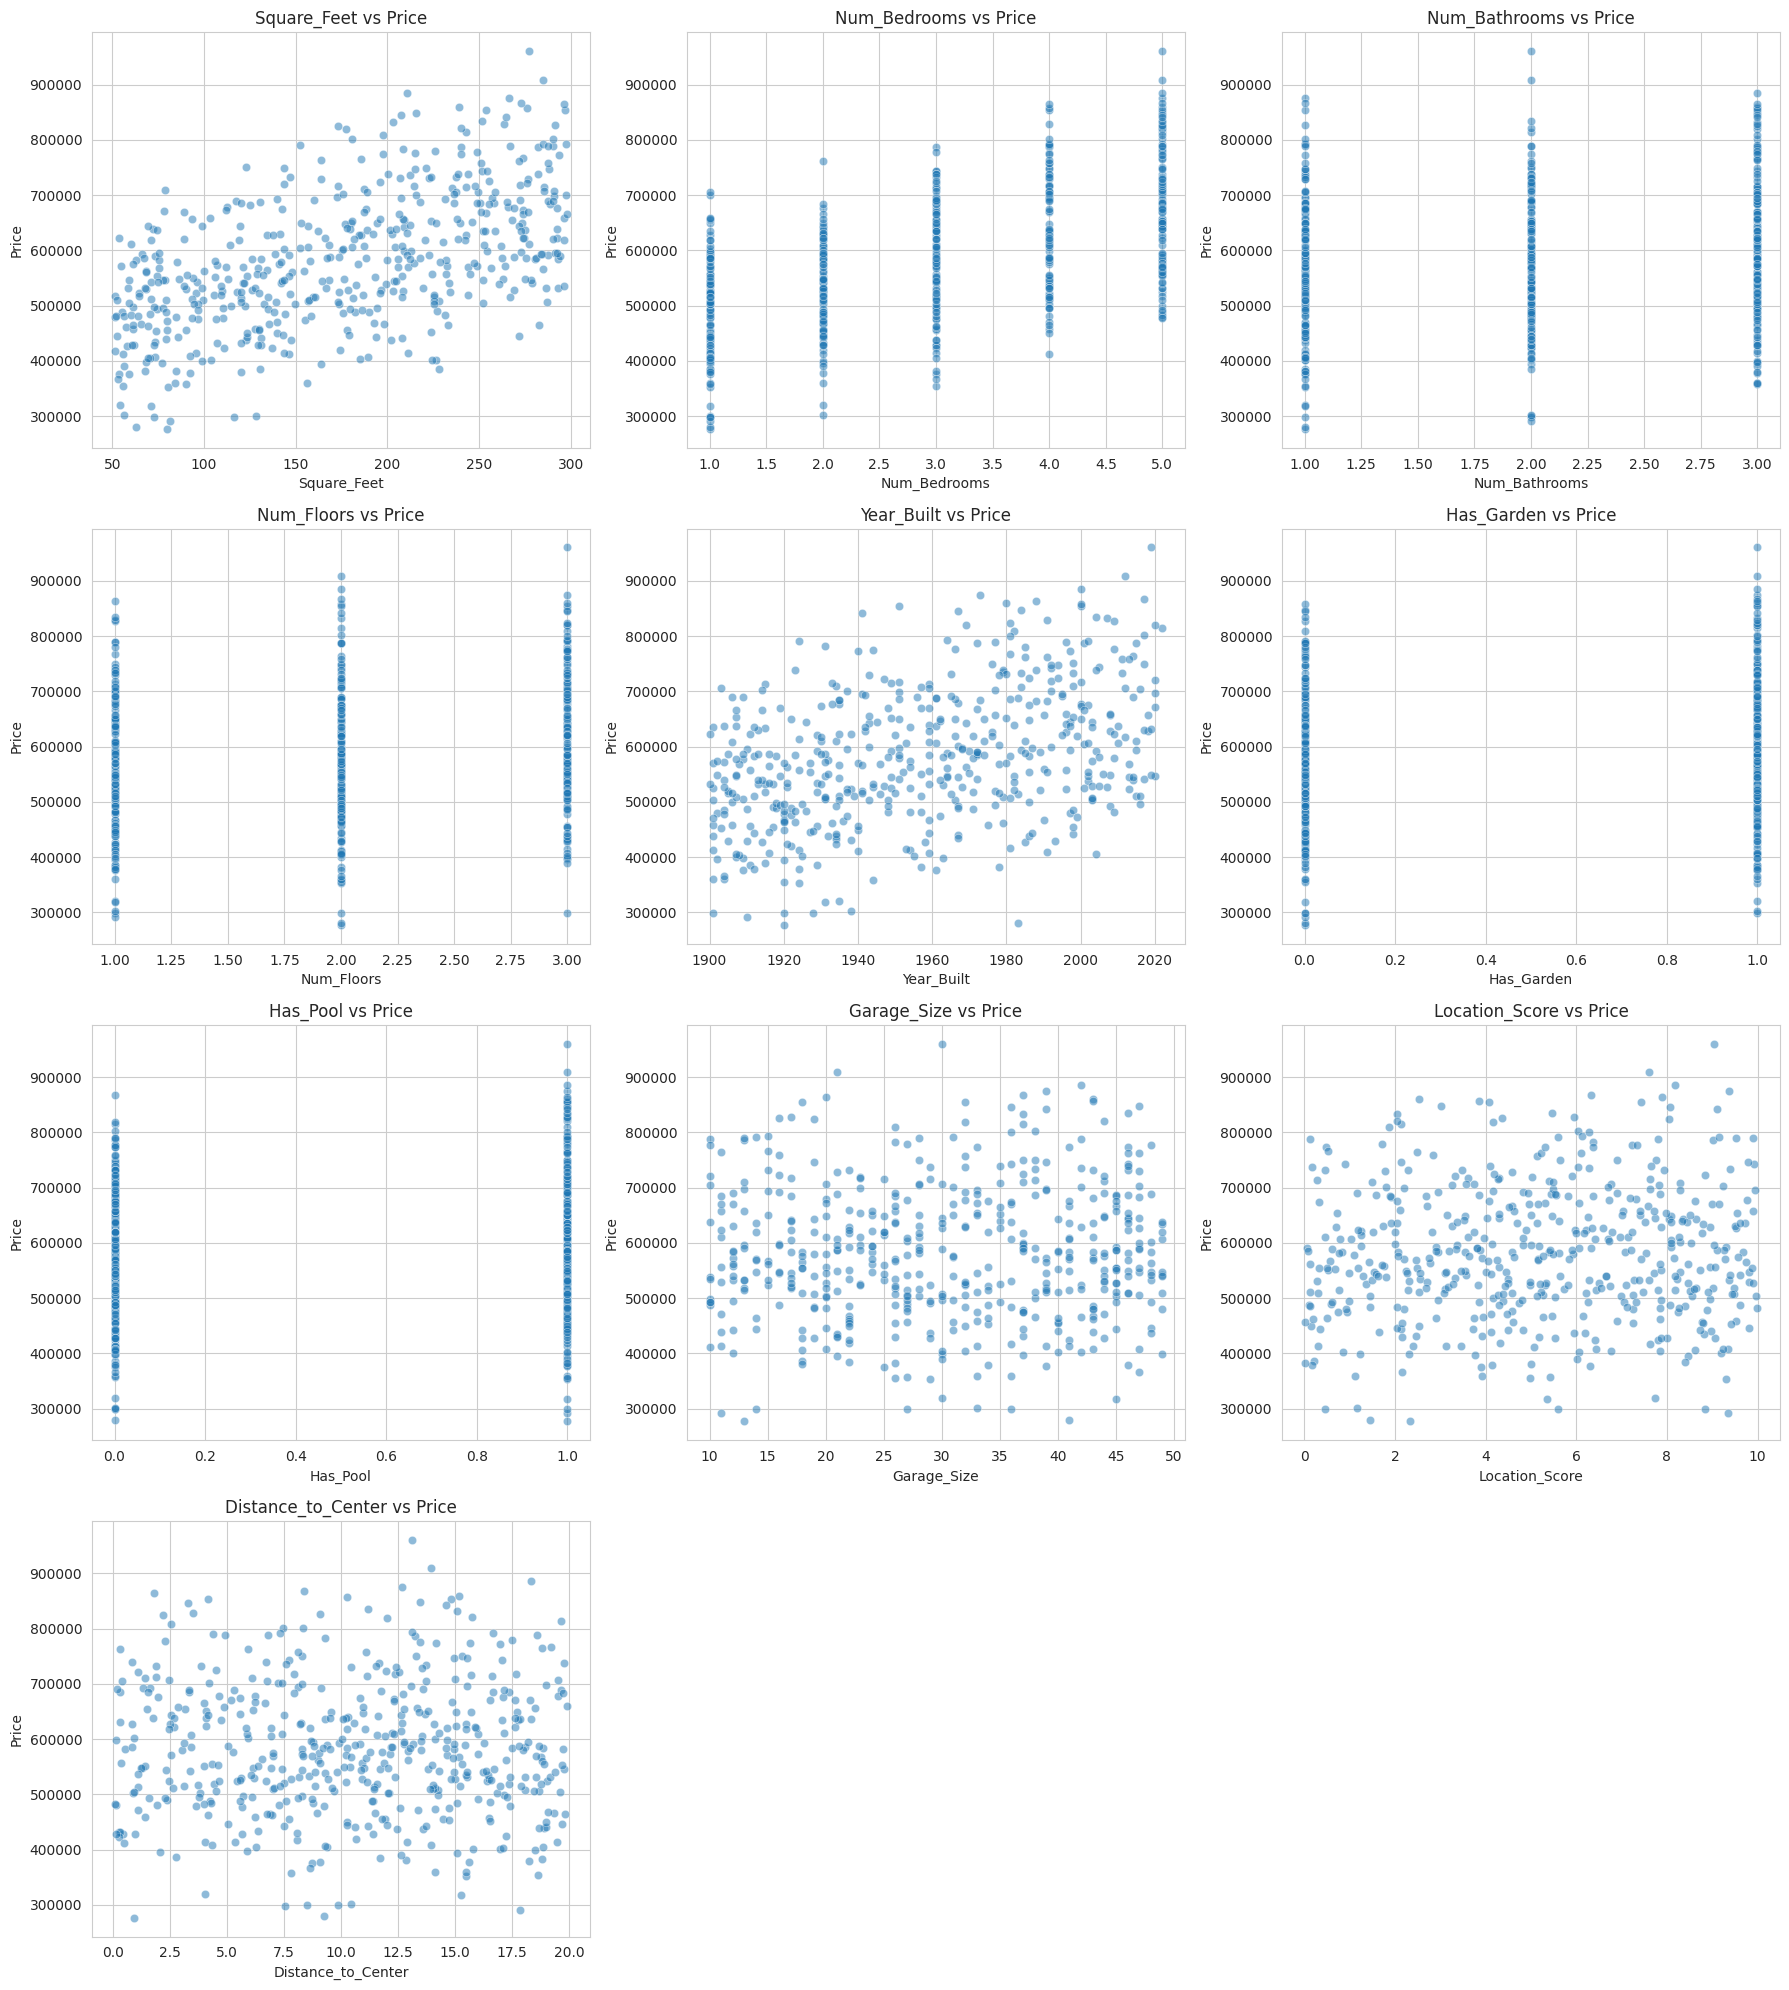

In [ ]:
target = 'Price'

features = [col for col in data.columns
            if col != target and data[col].dtype in ['float64', 'int64']]

num_features = len(features)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(data=data, x=feature, y=target, ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 5. Outlier Detection (IQR Method)

In [ ]:
def detect_outliers_iqr(df, cols):
    outlier_summary = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            'Count': len(outliers),
            'Percentage': round(len(outliers) / len(df) * 100, 2),
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        }
    return pd.DataFrame(outlier_summary).T

outlier_report = detect_outliers_iqr(data, features + [target])
print("Outlier Summary Report:")
print(outlier_report)

Outlier Summary Report:
                    Count  Percentage    Lower Bound    Upper Bound
Square_Feet           0.0         0.0     -82.747024     432.098167
Num_Bedrooms          0.0         0.0      -1.000000       7.000000
Num_Bathrooms         0.0         0.0      -2.000000       6.000000
Num_Floors            0.0         0.0      -2.000000       6.000000
Year_Built            0.0         0.0    1833.000000    2081.000000
Has_Garden            0.0         0.0      -1.500000       2.500000
Has_Pool              0.0         0.0      -1.500000       2.500000
Garage_Size           0.0         0.0     -11.500000      72.500000
Location_Score        0.0         0.0      -4.697776      15.191359
Distance_to_Center    0.0         0.0      -7.441999      28.581343
Price                 1.0         0.2  258787.408439  910235.236975


## 6. Skewness Check & Log Transformation (conditional)

Rather than hard-coding a fixed list of columns (as in the original life-expectancy version), we check skewness
programmatically and only log-transform columns that are actually skewed (|skew| > 1). `log1p` is used so any
zero values (e.g. `Has_Garden`, `Has_Pool`) are handled safely.

In [ ]:
skew_before = data[features + [target]].skew().sort_values(key=abs, ascending=False)
print("=== Skewness per column ===")
print(skew_before)

skew_threshold = 1.0
log_cols = [col for col in features
            if data[col].skew() > skew_threshold and (data[col] >= 0).all()]

if log_cols:
    print(f"\nApplying log1p transform to skewed columns: {log_cols}")
    for col in log_cols:
        data[col] = np.log1p(data[col])
else:
    print("\nNo columns exceed the |skew| > 1 threshold — log transformation is not needed for this dataset.")

=== Skewness per column ===
Price                 0.208609
Has_Garden           -0.144809
Distance_to_Center   -0.141340
Location_Score       -0.083641
Garage_Size          -0.068649
Num_Floors            0.065133
Year_Built            0.058171
Num_Bedrooms          0.057556
Num_Bathrooms         0.044404
Has_Pool              0.032100
Square_Feet          -0.025572
dtype: float64

No columns exceed the |skew| > 1 threshold — log transformation is not needed for this dataset.


## 7. Winsorization (conditional outlier capping)

Only cap columns where the IQR method flagged a meaningful share (>1%) of rows as outliers, instead of
winsorizing a fixed list of health columns that don't exist in this dataset.

In [ ]:
winsorize_cols = [col for col in features
                   if outlier_report.loc[col, 'Percentage'] > 1.0]

if winsorize_cols:
    print(f"Winsorizing columns with notable outliers: {winsorize_cols}")
    for col in winsorize_cols:
        data[col] = winsorize(data[col], limits=[0.05, 0.05])
else:
    print("No column has more than 1% outliers — winsorization is not needed for this dataset.")

# Save the processed dataset
data.to_csv('real_estate_dataset_processed.csv', index=False)
print("\nSaved processed data to 'real_estate_dataset_processed.csv'")

No column has more than 1% outliers — winsorization is not needed for this dataset.

Saved processed data to 'real_estate_dataset_processed.csv'


## 8. Feature Scaling (MinMaxScaler)

In [ ]:
data = pd.read_csv("real_estate_dataset_processed.csv")

numerical_features = [col for col in data.columns
                       if col != target and data[col].dtype in ['float64', 'int64']]

X_numerical = data[numerical_features].copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_numerical)

X_scaled_data = pd.DataFrame(X_scaled, columns=numerical_features, index=data.index)

print("=== Statistics After Scaling ===")
print(X_scaled_data.describe())

=== Statistics After Scaling ===
       Square_Feet  Num_Bedrooms  ...  Location_Score  Distance_to_Center
count   500.000000    500.000000  ...      500.000000          500.000000
mean      0.499543      0.489500  ...        0.516462            0.523873
std       0.302346      0.360242  ...        0.285606            0.281307
min       0.000000      0.000000  ...        0.000000            0.000000
25%       0.239111      0.250000  ...        0.275870            0.302235
50%       0.514324      0.500000  ...        0.520677            0.544836
75%       0.760260      0.750000  ...        0.773546            0.755583
max       1.000000      1.000000  ...        1.000000            1.000000

[8 rows x 10 columns]


## 9. Data Normalization (Standardization)\n\n`StandardScaler` centers the data around 0 with unit variance, which is what PCA expects.

In [ ]:
standard_scaler = StandardScaler()
X_normalized = standard_scaler.fit_transform(X_scaled_data)

X_normalized_data = pd.DataFrame(X_normalized, columns=numerical_features, index=X_scaled_data.index)

print("=== Statistics After Standardization ===")
print(X_normalized_data.describe())

print("\nMean values (should be close to 0):")
print(X_normalized_data.mean())
print("\nStd values (should be close to 1):")
print(X_normalized_data.std())

=== Statistics After Standardization ===
        Square_Feet  Num_Bedrooms  ...  Location_Score  Distance_to_Center
count  5.000000e+02  5.000000e+02  ...    5.000000e+02        5.000000e+02
mean   3.552714e-18 -2.664535e-17  ...   -4.831691e-16        3.197442e-17
std    1.001002e+00  1.001002e+00  ...    1.001002e+00        1.001002e+00
min   -1.653879e+00 -1.360170e+00  ...   -1.810118e+00       -1.864152e+00
25%   -8.622353e-01 -6.654967e-01  ...   -8.432371e-01       -7.886796e-01
50%    4.893615e-02  2.917626e-02  ...    1.477156e-02        7.459328e-02
75%    8.631775e-01  7.238492e-01  ...    9.010359e-01        8.245162e-01
max    1.656905e+00  1.418522e+00  ...    1.694721e+00        1.694249e+00

[8 rows x 10 columns]

Mean values (should be close to 0):
Square_Feet           3.552714e-18
Num_Bedrooms         -2.664535e-17
Num_Bathrooms         2.930989e-17
Num_Floors            5.861978e-17
Year_Built           -2.309264e-17
Has_Garden           -3.552714e-17
Has_Pool      

## 10. Correlation Analysis

In [ ]:
corr_data = X_normalized_data.copy()
corr_data[target] = data[target].values

correlation_matrix = corr_data.corr()

print("=== Correlation Matrix Shape ===")
print(f"Shape: {correlation_matrix.shape}")

print("\n=== Correlation with Target Variable (Price) ===")
target_corr = correlation_matrix[target].sort_values(ascending=False)
print(target_corr)

print("\n=== Strong Correlations with Target (|r| > 0.5) ===")
strong_corr = target_corr[(target_corr.abs() > 0.5) & (target_corr.index != target)]
print(strong_corr if len(strong_corr) else "None found above the 0.5 threshold")

=== Correlation Matrix Shape ===
Shape: (11, 11)

=== Correlation with Target Variable (Price) ===
Price                 1.000000
Num_Bedrooms          0.563973
Square_Feet           0.558604
Year_Built            0.418293
Num_Floors            0.177435
Num_Bathrooms         0.156689
Has_Pool              0.136579
Has_Garden            0.109196
Location_Score        0.071326
Garage_Size           0.032100
Distance_to_Center    0.000730
Name: Price, dtype: float64

=== Strong Correlations with Target (|r| > 0.5) ===
Num_Bedrooms    0.563973
Square_Feet     0.558604
Name: Price, dtype: float64


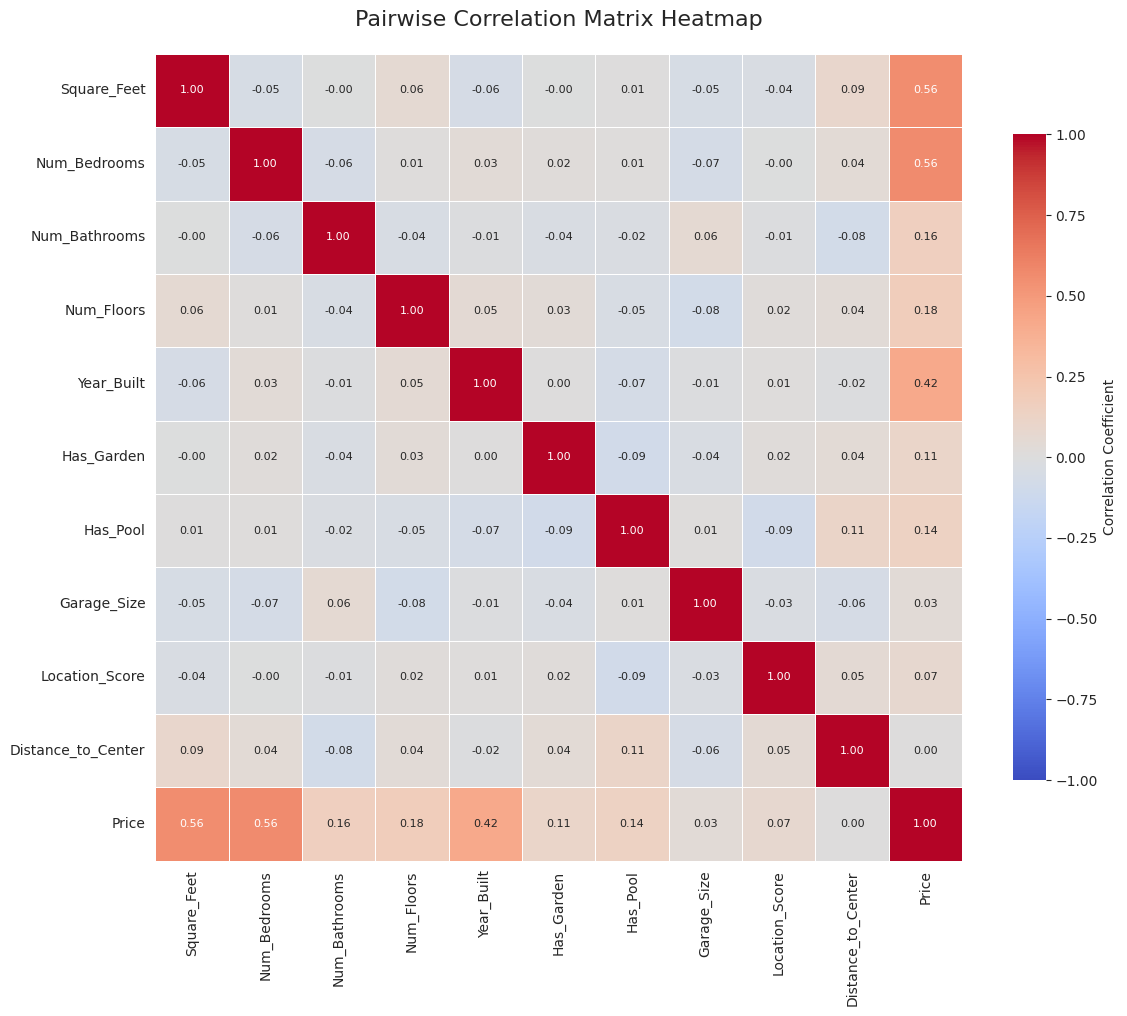

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            vmin=-1, vmax=1,
            annot_kws={"size": 8})

plt.title('Pairwise Correlation Matrix Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

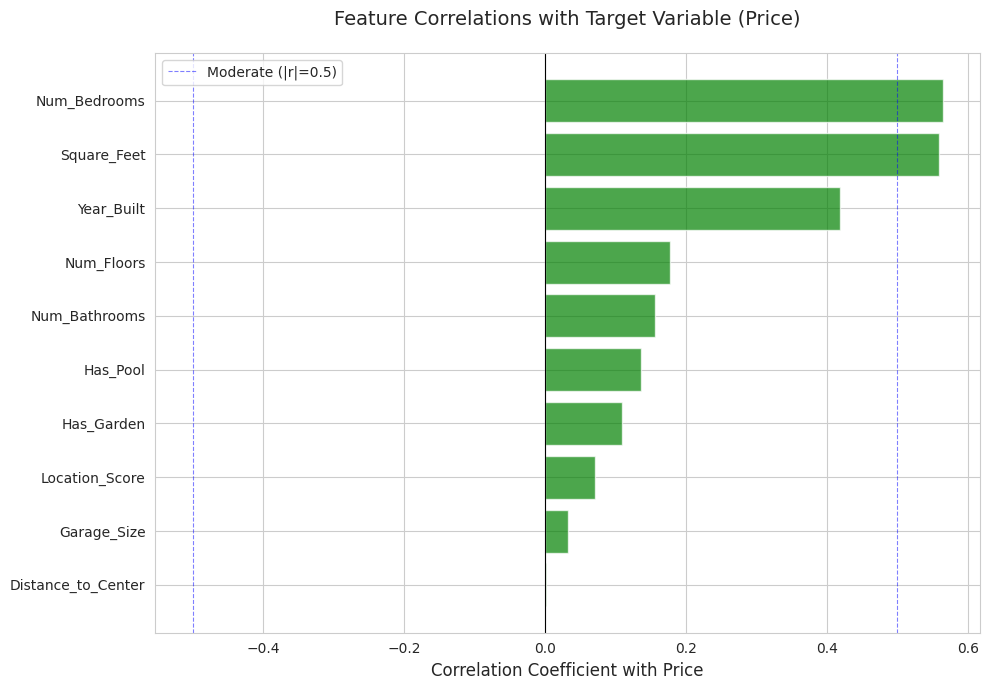

In [ ]:
plt.figure(figsize=(10, 7))

target_corr_no_target = target_corr.drop(target)
target_corr_sorted = target_corr_no_target.reindex(
    target_corr_no_target.abs().sort_values(ascending=True).index
)

colors = ['red' if x < 0 else 'green' for x in target_corr_sorted.values]

plt.barh(range(len(target_corr_sorted)), target_corr_sorted.values, color=colors, alpha=0.7)
plt.yticks(range(len(target_corr_sorted)), target_corr_sorted.index)
plt.xlabel('Correlation Coefficient with Price', fontsize=12)
plt.title('Feature Correlations with Target Variable (Price)', fontsize=14, pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=0.5, color='blue', linestyle='--', linewidth=0.8, alpha=0.5, label='Moderate (|r|=0.5)')
plt.axvline(x=-0.5, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 11. PCA — Eigen Decomposition

Compute the covariance matrix of the standardized features and its eigenvalues/eigenvectors. The eigenvalues tell us how much variance each new (principal) axis captures; the eigenvectors (loadings) tell us how the original features combine to form each principal component.


In [ ]:
cov_matrix = np.cov(X_normalized_data.T)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# np.linalg.eigh returns eigenvalues in ascending order — sort descending instead
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Eigenvalues:")
print(eigenvalues)

loading_matrix = pd.DataFrame(
    eigenvectors,
    index=numerical_features,
    columns=[f"PC{i}" for i in range(1, len(eigenvalues) + 1)]
)
print("\n=== Loading matrix (first 4 components) ===")
print(loading_matrix.iloc[:, :4].round(3))


## 12. Explained Variance from Eigenvalues

In [ ]:
explained_variance_ratio_eig = eigenvalues / np.sum(eigenvalues)
print("Explained Variance Ratio (from eigen decomposition):")
print(explained_variance_ratio_eig)

Explained Variance Ratio (from eigen decomposition):
[0.00104182 0.17565789 0.11108503 0.10884459 0.07359781 0.09902283
 0.08094929 0.08195809 0.08703965 0.08976401 0.09103899]


## 13. Selecting the Number of Principal Components

Choose the smallest number of components that together explain at least 95% of the total variance.


In [ ]:
cumulative_variance = np.cumsum(explained_variance_ratio_eig)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

print("Cumulative explained variance by component:")
for i, c in enumerate(cumulative_variance, 1):
    print(f"  PC1..PC{i}: {c:.4f}")

print(f"\nComponents needed for >=95% variance: {n_components_95} out of {len(numerical_features)}")


## 14. Predictive Modeling — PCA + Linear Regression

Reduce the standardized features to `n_components_95` principal components, then fit a linear regression on those components, for comparison against the baseline model that uses all original (standardized) features.


In [ ]:
X_all = X_normalized_data.values
y_all = data[target].values

X_train_full, X_test_full, y_train_pca, y_test_pca = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

pca_model = PCA(n_components=n_components_95)
X_train_pca = pca_model.fit_transform(X_train_full)
X_test_pca = pca_model.transform(X_test_full)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train_pca)

train_r2_pca = r2_score(y_train_pca, lr_pca.predict(X_train_pca))
test_r2_pca = r2_score(y_test_pca, lr_pca.predict(X_test_pca))

print(f"PCA-based model — Train R^2: {train_r2_pca:.4f}  Test R^2: {test_r2_pca:.4f}")
print(f"(Uses {n_components_95} of {len(numerical_features)} original dimensions)")


## 15. Predictive Modeling — Linear Regression

A quick baseline model to see how well the standardized features predict `Price` (this uses the
`train_test_split`, `LinearRegression`, and `r2_score` imports that were set up at the top of the notebook).

In [ ]:
X = X_normalized_data.values
y = data[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

train_r2 = r2_score(y_train, lr.predict(X_train))
test_r2 = r2_score(y_test, lr.predict(X_test))

print(f"Train R^2: {train_r2:.4f}")
print(f"Test R^2:  {test_r2:.4f}")

coef_df = pd.Series(lr.coef_, index=numerical_features).sort_values(key=abs, ascending=False)
print("\n=== Linear Regression Coefficients (standardized features) ===")
print(coef_df)

Train R^2: 0.9767
Test R^2:  0.9709

=== Linear Regression Coefficients (standardized features) ===
Square_Feet           75321.629977
Num_Bedrooms          72280.149107
Year_Built            53342.571715
Num_Bathrooms         24867.544153
Has_Pool              23120.918077
Num_Floors            15913.242426
Has_Garden            15133.817246
Location_Score        13648.948501
Garage_Size           13134.162319
Distance_to_Center   -10513.851799
dtype: float64
